# Analyse: Konsistenz textuell genannter LLM-Quellen

Dieses Notebook analysiert die erhobenen Gemini-Antworten ohne Google Search Grounding. Quellen werden als URLs aus dem Antworttext ausgewertet (`source_extraction_method = text_regex`).

**Wichtig für die Methodik:** Die Analyse misst die Stabilität der im generierten Text genannten URLs/Domains, nicht die Stabilität von Grounding-Metadaten oder live abgerufenen Suchergebnissen.

In [3]:
from pathlib import Path
from itertools import combinations
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt

RAW_FILE = Path('../data/raw/raw_runs_no_grounding_temp1.jsonl')
SOURCES_FILE = Path('../data/processed/sources_no_grounding_temp1.csv')
ANALYSIS_DIR = Path('../data/analysis')
FIGURES_DIR = ANALYSIS_DIR / 'figures'

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)

## 1. Daten laden und Grundcheck

In [4]:
def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    with path.open('r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

raw = load_jsonl(RAW_FILE)
sources = pd.read_csv(SOURCES_FILE)

raw['timestamp'] = pd.to_datetime(raw['timestamp'], errors='coerce')
sources['timestamp'] = pd.to_datetime(sources['timestamp'], errors='coerce')

print('Rohdaten:', raw.shape)
print('Quellen:', sources.shape)
display(raw.head())
display(sources.head())

Rohdaten: (200, 13)
Quellen: (726, 10)


,prompt_id,category,prompt,run_id,timestamp,system,model,temperature,max_output_tokens,response_text,sources,raw_response,error
0,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R01,2026-06-16 17:35:09.390179+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,1.0,8165,Der aktuelle wissenschaftliche Kenntnisstand zum Klimawandel ist so präzise wie nie zuvor. Die internationale Wissen...,"[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/syr/', 'domain': 'ipcc.ch', 'title': None, 'source_extra...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
1,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R02,2026-06-16 17:35:19.175855+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,1.0,8165,"Die wissenschaftliche Gemeinschaft ist sich einig, dass der Klimawandel real ist, vom Menschen verursacht wird und e...","[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/wg1/', 'domain': 'ipcc.ch', 'title': None, 'source_extra...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
2,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R03,2026-06-16 17:35:28.348043+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,1.0,8165,Die wissenschaftlichen Erkenntnisse zum Klimawandel sind heute so fundiert wie kaum ein anderes Gebiet der Naturwiss...,"[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/syr/', 'domain': 'ipcc.ch', 'title': None, 'source_extra...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
3,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R04,2026-06-16 17:35:38.011909+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,1.0,8165,Die wissenschaftliche Erkenntnis zum Klimawandel ist heute so fundiert wie kaum ein anderes Forschungsfeld. Der aktu...,"[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/syr/', 'domain': 'ipcc.ch', 'title': None, 'source_extra...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
4,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R05,2026-06-16 17:35:47.819927+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,1.0,8165,"Die wissenschaftliche Gemeinschaft ist sich einig, dass der Klimawandel real ist, vom Menschen verursacht wurde und ...","[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/syr/downloads/report/IPCC_AR6_SYR_SPM.pdf', 'domain': 'i...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None


,prompt_id,category,run_id,timestamp,model,source_index,url,domain,title,source_extraction_method
0,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,0,https://www.ipcc.ch/report/ar6/syr/,ipcc.ch,NaN,text_regex
1,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,1,https://www.deutsches-klima-konsortium.de/de/klimawissen.html,deutsches-klima-konsortium.de,NaN,text_regex
2,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,2,https://climate.nasa.gov/,climate.nasa.gov,NaN,text_regex
3,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,3,https://public.wmo.int/en/our-mandate/climate/wmo-statement-state-of-global-climate,public.wmo.int,NaN,text_regex
4,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,4,https://www.klimafakten.de/,klimafakten.de,NaN,text_regex


In [5]:
overview = pd.DataFrame({
    'metric': [
        'Prompts',
        'Runs',
        'Kategorien',
        'Modelle',
        'Antworten mit Fehler',
        'Extrahierte URL-Nennungen',
        'Einzigartige URLs',
        'Einzigartige Domains',
        'Erster Timestamp',
        'Letzter Timestamp',
    ],
    'value': [
        raw['prompt_id'].nunique(),
        raw['run_id'].nunique(),
        raw['category'].nunique(),
        raw['model'].nunique(),
        raw['error'].notna().sum(),
        len(sources),
        sources['url'].nunique(),
        sources['domain'].nunique(),
        raw['timestamp'].min(),
        raw['timestamp'].max(),
    ]
})

overview.to_csv(ANALYSIS_DIR / 'overview.csv', index=False)
display(overview)

,metric,value
0,Prompts,10
1,Runs,200
2,Kategorien,3
3,Modelle,1
4,Antworten mit Fehler,0
5,Extrahierte URL-Nennungen,726
6,Einzigartige URLs,366
7,Einzigartige Domains,85
8,Erster Timestamp,2026-06-16 17:35:09.390179+00:00
9,Letzter Timestamp,2026-06-16 18:15:34.540370+00:00


## 2. Vollständigkeit: Wie viele Runs gibt es pro Prompt?

In [6]:
runs_by_prompt = (
    raw.groupby(['prompt_id', 'category'])
    .agg(
        n_runs=('run_id', 'nunique'),
        errors=('error', lambda x: x.notna().sum()),
        first_timestamp=('timestamp', 'min'),
        last_timestamp=('timestamp', 'max'),
    )
    .reset_index()
)

runs_by_prompt.to_csv(ANALYSIS_DIR / 'runs_by_prompt.csv', index=False)
display(runs_by_prompt)

,prompt_id,category,n_runs,errors,first_timestamp,last_timestamp
0,P01,Faktische Frage,20,0,2026-06-16 17:35:09.390179+00:00,2026-06-16 17:39:58.634559+00:00
1,P02,Faktische Frage,20,0,2026-06-16 17:40:07.910646+00:00,2026-06-16 17:42:12.960946+00:00
2,P03,Faktische Frage,20,0,2026-06-16 17:42:26.381221+00:00,2026-06-16 17:45:06.532648+00:00
3,P04,Faktische Frage,20,0,2026-06-16 17:45:13.000157+00:00,2026-06-16 17:49:22.278242+00:00
4,P05,Prozedurale Frage,20,0,2026-06-16 17:49:30.289214+00:00,2026-06-16 17:52:20.651167+00:00
5,P06,Prozedurale Frage,20,0,2026-06-16 17:52:28.861587+00:00,2026-06-16 17:58:20.908480+00:00
6,P07,Prozedurale Frage,20,0,2026-06-16 17:58:29.856134+00:00,2026-06-16 18:04:05.598737+00:00
7,P08,Aktuelles Thema,20,0,2026-06-16 18:04:14.493091+00:00,2026-06-16 18:07:18.826320+00:00
8,P09,Aktuelles Thema,20,0,2026-06-16 18:07:26.455657+00:00,2026-06-16 18:10:12.657114+00:00
9,P10,Aktuelles Thema,20,0,2026-06-16 18:10:20.581505+00:00,2026-06-16 18:15:34.540370+00:00


## 3. Quellenmenge pro Run

In [7]:
sources_per_run = (
    sources.groupby(['prompt_id', 'category', 'run_id'])
    .agg(
        n_url_mentions=('url', 'count'),
        n_unique_urls=('url', 'nunique'),
        n_unique_domains=('domain', 'nunique'),
    )
    .reset_index()
)

sources_per_prompt = (
    sources_per_run.groupby(['prompt_id', 'category'])
    .agg(
        min_urls=('n_unique_urls', 'min'),
        max_urls=('n_unique_urls', 'max'),
        mean_urls=('n_unique_urls', 'mean'),
        min_domains=('n_unique_domains', 'min'),
        max_domains=('n_unique_domains', 'max'),
        mean_domains=('n_unique_domains', 'mean'),
        min_url_mentions=('n_url_mentions', 'min'),
        max_url_mentions=('n_url_mentions', 'max'),
        mean_url_mentions=('n_url_mentions', 'mean'),
    )
    .reset_index()
)

sources_per_run.to_csv(ANALYSIS_DIR / 'sources_per_run.csv', index=False)
sources_per_prompt.to_csv(ANALYSIS_DIR / 'sources_per_prompt.csv', index=False)

display(sources_per_prompt)

,prompt_id,category,min_urls,max_urls,mean_urls,min_domains,max_domains,mean_domains,min_url_mentions,max_url_mentions,mean_url_mentions
0,P01,Faktische Frage,5,10,7.10,5,8,6.05,5,10,7.10
1,P02,Faktische Frage,2,3,2.25,2,3,2.25,2,3,2.25
2,P03,Faktische Frage,1,3,1.65,1,2,1.10,1,3,1.65
3,P04,Faktische Frage,2,3,2.40,1,3,2.30,2,3,2.40
4,P05,Prozedurale Frage,2,5,3.80,1,3,1.60,2,5,3.80
5,P06,Prozedurale Frage,2,5,3.15,2,4,2.85,2,5,3.15
6,P07,Prozedurale Frage,1,5,2.55,1,2,1.05,1,5,2.55
7,P08,Aktuelles Thema,3,4,3.50,3,4,3.50,3,4,3.50
8,P09,Aktuelles Thema,3,6,4.45,3,6,4.45,3,6,4.45
9,P10,Aktuelles Thema,4,8,5.45,3,5,4.35,4,8,5.45


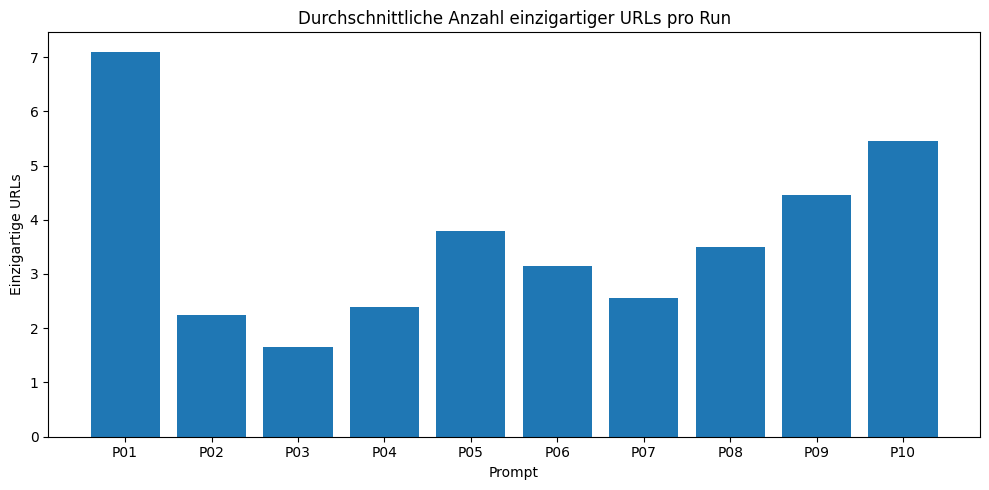

In [8]:
plot_data = sources_per_prompt.sort_values('prompt_id')

plt.figure(figsize=(10, 5))
plt.bar(plot_data['prompt_id'], plot_data['mean_urls'])
plt.title('Durchschnittliche Anzahl einzigartiger URLs pro Run')
plt.xlabel('Prompt')
plt.ylabel('Einzigartige URLs')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mean_unique_urls_by_prompt.png', dpi=200)
plt.show()

## 4. Häufigste Domains und URLs

In [9]:
top_domains = (
    sources.groupby('domain')
    .agg(
        occurrences=('domain', 'count'),
        prompts=('prompt_id', 'nunique'),
        runs=('run_id', 'nunique'),
    )
    .reset_index()
    .sort_values(['occurrences', 'prompts'], ascending=False)
)

top_urls = (
    sources.groupby('url')
    .agg(
        occurrences=('url', 'count'),
        prompts=('prompt_id', 'nunique'),
        runs=('run_id', 'nunique'),
        domain=('domain', 'first'),
    )
    .reset_index()
    .sort_values(['occurrences', 'prompts'], ascending=False)
)

top_domains.to_csv(ANALYSIS_DIR / 'top_domains.csv', index=False)
top_urls.to_csv(ANALYSIS_DIR / 'top_urls.csv', index=False)

display(top_domains.head(30))
display(top_urls.head(30))

,domain,occurrences,prompts,runs
2,arbeitsagentur.de,64,1,20
60,service.berlin.de,50,1,20
42,ipcc.ch,37,1,20
62,statistik-berlin-brandenburg.de,31,1,20
66,tagesschau.de,29,1,20
11,bundesnetzagentur.de,24,2,24
77,verbraucherzentrale.de,24,1,20
23,climate.nasa.gov,23,1,20
13,bundesregierung.de,21,2,14
34,gesetze-im-internet.de,21,2,19


,url,occurrences,prompts,runs,domain
20,https://service.berlin.de/dienstleistung/120686/,20,1,20,service.berlin.de
87,https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html,20,1,20,bmas.de
187,https://www.kino.de/kinoprogramm/,19,1,19,kino.de
4,https://climate.nasa.gov/,18,1,18,climate.nasa.gov
135,https://www.clever-tanken.de/,15,1,15,clever-tanken.de
179,https://www.ipcc.ch/report/ar6/syr/,14,1,14,ipcc.ch
190,https://www.mehr-tanken.de/,14,1,14,mehr-tanken.de
165,https://www.gesetze-im-internet.de/tkg_2021/__56.html,12,1,12,gesetze-im-internet.de
25,https://service.berlin.de/standorte/buergeraemter/,10,1,10,service.berlin.de
99,https://www.bundesnetzagentur.de/DE/Vportal/TK/Abrechnung/Vertrag/start.html,10,1,10,bundesnetzagentur.de


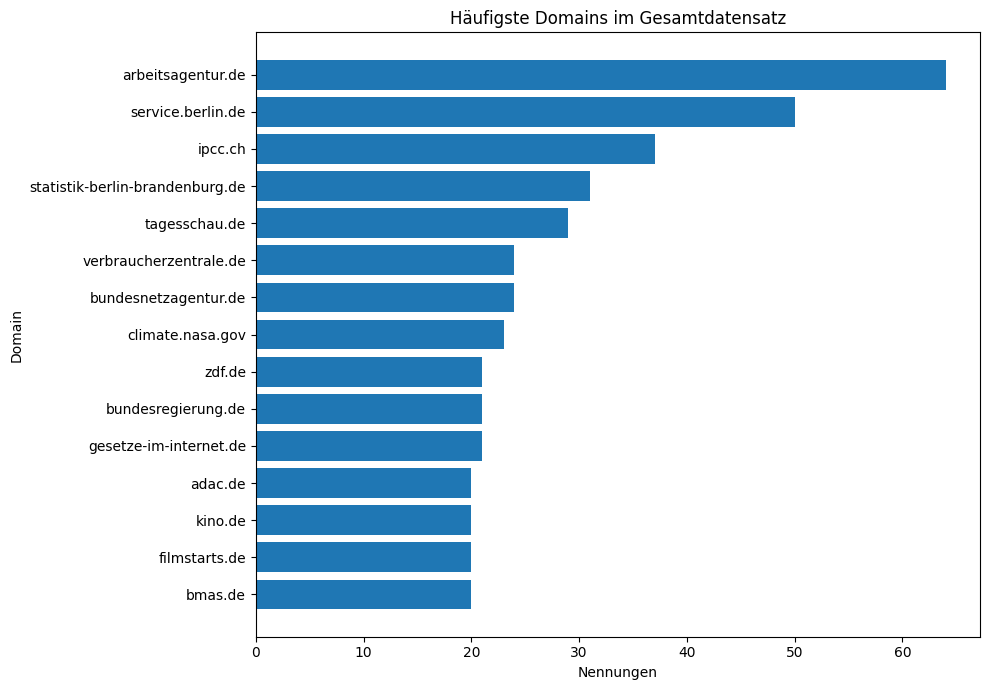

In [10]:
plot_data = top_domains.head(15).sort_values('occurrences')

plt.figure(figsize=(10, 7))
plt.barh(plot_data['domain'], plot_data['occurrences'])
plt.title('Häufigste Domains im Gesamtdatensatz')
plt.xlabel('Nennungen')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_domains.png', dpi=200)
plt.show()

## 5. Coverage: Welche Domains/URLs erscheinen in wie vielen Runs?

In [11]:
total_runs_by_prompt = raw.groupby('prompt_id')['run_id'].nunique().rename('total_runs')

domain_coverage = (
    sources.groupby(['prompt_id', 'category', 'domain'])
    .agg(
        occurrences=('domain', 'count'),
        runs=('run_id', 'nunique'),
    )
    .reset_index()
    .merge(total_runs_by_prompt, on='prompt_id', how='left')
)
domain_coverage['run_coverage'] = domain_coverage['runs'] / domain_coverage['total_runs']
domain_coverage = domain_coverage.sort_values(['prompt_id', 'run_coverage', 'occurrences'], ascending=[True, False, False])

url_coverage = (
    sources.groupby(['prompt_id', 'category', 'url', 'domain'])
    .agg(
        occurrences=('url', 'count'),
        runs=('run_id', 'nunique'),
    )
    .reset_index()
    .merge(total_runs_by_prompt, on='prompt_id', how='left')
)
url_coverage['run_coverage'] = url_coverage['runs'] / url_coverage['total_runs']
url_coverage = url_coverage.sort_values(['prompt_id', 'run_coverage', 'occurrences'], ascending=[True, False, False])

domain_coverage.to_csv(ANALYSIS_DIR / 'domain_coverage.csv', index=False)
url_coverage.to_csv(ANALYSIS_DIR / 'url_coverage.csv', index=False)

display(domain_coverage)
display(url_coverage)

,prompt_id,category,domain,occurrences,runs,total_runs,run_coverage
9,P01,Faktische Frage,ipcc.ch,37,20,20,1.00
3,P01,Faktische Frage,climate.nasa.gov,23,20,20,1.00
4,P01,Faktische Frage,deutsches-klima-konsortium.de,10,10,20,0.50
6,P01,Faktische Frage,dwd.de,9,9,20,0.45
1,P01,Faktische Frage,climate.copernicus.eu,8,8,20,0.40
0,P01,Faktische Frage,carbonbrief.org,6,6,20,0.30
10,P01,Faktische Frage,klimafakten.de,6,6,20,0.30
16,P01,Faktische Frage,umweltbundesamt.de,6,6,20,0.30
12,P01,Faktische Frage,pik-potsdam.de,6,5,20,0.25
13,P01,Faktische Frage,public.wmo.int,5,5,20,0.25


,prompt_id,category,url,domain,occurrences,runs,total_runs,run_coverage
3,P01,Faktische Frage,https://climate.nasa.gov/,climate.nasa.gov,18,18,20,0.90
34,P01,Faktische Frage,https://www.ipcc.ch/report/ar6/syr/,ipcc.ch,14,14,20,0.70
37,P01,Faktische Frage,https://www.ipcc.ch/report/ar6/wg1/,ipcc.ch,9,9,20,0.45
0,P01,Faktische Frage,https://climate.copernicus.eu/,climate.copernicus.eu,6,6,20,0.30
40,P01,Faktische Frage,https://www.klimafakten.de/,klimafakten.de,6,6,20,0.30
...,...,...,...,...,...,...,...,...
361,P10,Aktuelles Thema,https://www.zeit.de/politik/deutschland/2024-11/haushaltsnotlage-bundestagswahl-olaf-scholz-union,zeit.de,1,1,20,0.05
362,P10,Aktuelles Thema,https://www.zeit.de/politik/deutschland/2024-11/olaf-scholz-bundestagswahl-haushalt-opposition,zeit.de,1,1,20,0.05
363,P10,Aktuelles Thema,https://www.zeit.de/politik/deutschland/2024-11/olaf-scholz-ukraine-taurus-fernwaffen-debatte,zeit.de,1,1,20,0.05
364,P10,Aktuelles Thema,https://www.zeit.de/politik/deutschland/2024-11/schuldenbremse-reform-ampel-aus-union-widerstand,zeit.de,1,1,20,0.05


## 6. Stabilität: Jaccard-Ähnlichkeit zwischen Runs

In [12]:
def jaccard(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def pairwise_stability(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    rows = []
    grouped = (
        df.groupby(['prompt_id', 'category', 'run_id'])[value_col]
        .apply(lambda x: set(x.dropna()))
        .reset_index(name='values')
    )

    for (prompt_id, category), group in grouped.groupby(['prompt_id', 'category']):
        run_values = dict(zip(group['run_id'], group['values']))
        for run_a, run_b in combinations(sorted(run_values.keys()), 2):
            score = jaccard(run_values[run_a], run_values[run_b])
            rows.append({
                'prompt_id': prompt_id,
                'category': category,
                'run_a': run_a,
                'run_b': run_b,
                'value_type': value_col,
                'jaccard': score,
                'has_overlap': score > 0,
            })
    return pd.DataFrame(rows)

url_pairwise = pairwise_stability(sources, 'url')
domain_pairwise = pairwise_stability(sources, 'domain')

stability_by_prompt = (
    url_pairwise.groupby(['prompt_id', 'category'])
    .agg(
        n_pairs=('jaccard', 'count'),
        mean_url_jaccard=('jaccard', 'mean'),
        min_url_jaccard=('jaccard', 'min'),
        max_url_jaccard=('jaccard', 'max'),
        url_pair_overlap_rate=('has_overlap', 'mean'),
    )
    .reset_index()
    .merge(
        domain_pairwise.groupby(['prompt_id', 'category'])
        .agg(
            mean_domain_jaccard=('jaccard', 'mean'),
            min_domain_jaccard=('jaccard', 'min'),
            max_domain_jaccard=('jaccard', 'max'),
            domain_pair_overlap_rate=('has_overlap', 'mean'),
        )
        .reset_index(),
        on=['prompt_id', 'category'],
        how='left'
    )
)

url_pairwise.to_csv(ANALYSIS_DIR / 'url_pairwise_jaccard.csv', index=False)
domain_pairwise.to_csv(ANALYSIS_DIR / 'domain_pairwise_jaccard.csv', index=False)
stability_by_prompt.to_csv(ANALYSIS_DIR / 'stability_by_prompt.csv', index=False)

display(stability_by_prompt)

,prompt_id,category,n_pairs,mean_url_jaccard,min_url_jaccard,max_url_jaccard,url_pair_overlap_rate,mean_domain_jaccard,min_domain_jaccard,max_domain_jaccard,domain_pair_overlap_rate
0,P01,Faktische Frage,190,0.186607,0.000000,0.666667,0.947368,0.357611,0.166667,1.0,1.000000
1,P02,Faktische Frage,190,0.301316,0.200000,1.000000,1.000000,0.442018,0.200000,1.0,1.000000
2,P03,Faktische Frage,190,0.010526,0.000000,0.500000,0.031579,0.901754,0.333333,1.0,1.000000
3,P04,Faktische Frage,190,0.097105,0.000000,1.000000,0.305263,0.581930,0.000000,1.0,0.968421
4,P05,Prozedurale Frage,190,0.056876,0.000000,0.400000,0.342105,0.572105,0.200000,1.0,1.000000
5,P06,Prozedurale Frage,190,0.125347,0.000000,0.500000,0.531579,0.811404,0.333333,1.0,1.000000
6,P07,Prozedurale Frage,190,0.433434,0.166667,1.000000,1.000000,0.950000,0.500000,1.0,1.000000
7,P08,Aktuelles Thema,190,0.260702,0.000000,1.000000,0.721053,0.559123,0.166667,1.0,1.000000
8,P09,Aktuelles Thema,190,0.193993,0.000000,0.714286,0.926316,0.509129,0.250000,1.0,1.000000
9,P10,Aktuelles Thema,190,0.012673,0.000000,0.272727,0.094737,0.571021,0.125000,1.0,1.000000


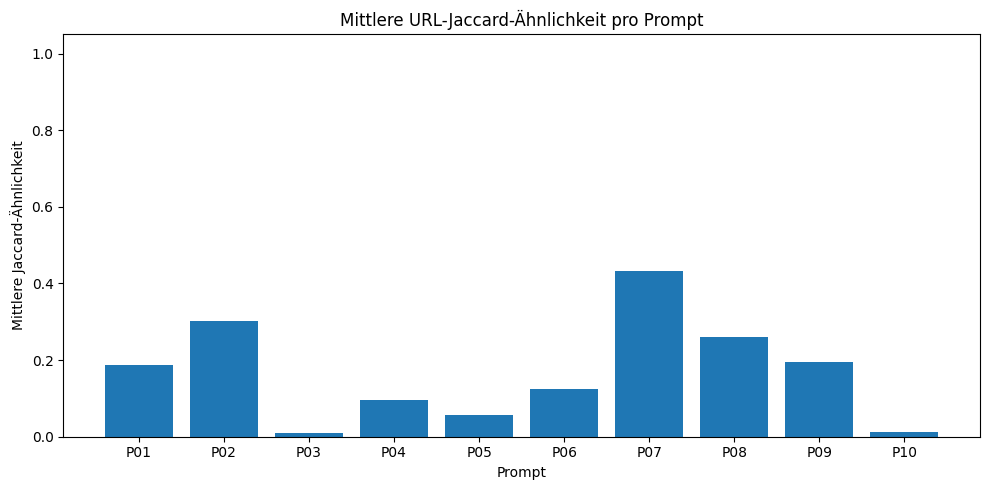

In [13]:
plot_data = stability_by_prompt.sort_values('prompt_id')

plt.figure(figsize=(10, 5))
plt.bar(plot_data['prompt_id'], plot_data['mean_url_jaccard'])
plt.title('Mittlere URL-Jaccard-Ähnlichkeit pro Prompt')
plt.xlabel('Prompt')
plt.ylabel('Mittlere Jaccard-Ähnlichkeit')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mean_url_jaccard_by_prompt.png', dpi=200)
plt.show()

## 7. Set-Varianten: Waren die URL-/Domain-Mengen wirklich identisch?

In [14]:
url_sets = (
    sources.groupby(['prompt_id', 'category', 'run_id'])['url']
    .apply(lambda x: tuple(sorted(set(x.dropna()))))
    .reset_index(name='url_set')
)

domain_sets = (
    sources.groupby(['prompt_id', 'category', 'run_id'])['domain']
    .apply(lambda x: tuple(sorted(set(x.dropna()))))
    .reset_index(name='domain_set')
)

set_variants = (
    url_sets.groupby(['prompt_id', 'category'])['url_set']
    .nunique()
    .reset_index(name='different_url_sets')
    .merge(
        domain_sets.groupby(['prompt_id', 'category'])['domain_set']
        .nunique()
        .reset_index(name='different_domain_sets'),
        on=['prompt_id', 'category'],
        how='left'
    )
)

set_variants.to_csv(ANALYSIS_DIR / 'set_variants_by_prompt.csv', index=False)
display(set_variants)

# Interpretation:
# different_url_sets = 1 bedeutet: Alle Runs eines Prompts hatten exakt dieselbe URL-Menge.
# different_domain_sets = 1 bedeutet: Alle Runs eines Prompts hatten exakt dieselbe Domain-Menge.

,prompt_id,category,different_url_sets,different_domain_sets
0,P01,Faktische Frage,20,19
1,P02,Faktische Frage,19,10
2,P03,Faktische Frage,20,3
3,P04,Faktische Frage,19,8
4,P05,Prozedurale Frage,20,8
5,P06,Prozedurale Frage,20,4
6,P07,Prozedurale Frage,12,2
7,P08,Aktuelles Thema,17,10
8,P09,Aktuelles Thema,20,13
9,P10,Aktuelles Thema,20,14


## 8. Antworttext-Variation

In [15]:
def sha256_text(value) -> str:
    text = '' if pd.isna(value) else str(value)
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

raw['response_text_clean'] = raw['response_text'].fillna('')
raw['response_hash'] = raw['response_text_clean'].apply(sha256_text)
raw['response_length_chars'] = raw['response_text_clean'].str.len()

text_variants = (
    raw.groupby(['prompt_id', 'category'])
    .agg(
        n_runs=('run_id', 'nunique'),
        different_response_texts=('response_hash', 'nunique'),
        min_response_length=('response_length_chars', 'min'),
        max_response_length=('response_length_chars', 'max'),
        mean_response_length=('response_length_chars', 'mean'),
    )
    .reset_index()
)

text_variants['all_response_texts_identical'] = text_variants['different_response_texts'] == 1

text_variants.to_csv(ANALYSIS_DIR / 'text_variants_by_prompt.csv', index=False)
display(text_variants)

,prompt_id,category,n_runs,different_response_texts,min_response_length,max_response_length,mean_response_length,all_response_texts_identical
0,P01,Faktische Frage,20,20,3443,4506,4012.65,False
1,P02,Faktische Frage,20,20,556,872,682.65,False
2,P03,Faktische Frage,20,20,528,1156,844.60,False
3,P04,Faktische Frage,20,20,1324,2368,1859.75,False
4,P05,Prozedurale Frage,20,20,2669,3337,2985.20,False
5,P06,Prozedurale Frage,20,20,2794,3628,3295.00,False
6,P07,Prozedurale Frage,20,20,2335,3305,2780.35,False
7,P08,Aktuelles Thema,20,20,1467,2377,1905.00,False
8,P09,Aktuelles Thema,20,20,1641,2324,1975.40,False
9,P10,Aktuelles Thema,20,20,2723,3589,3148.65,False


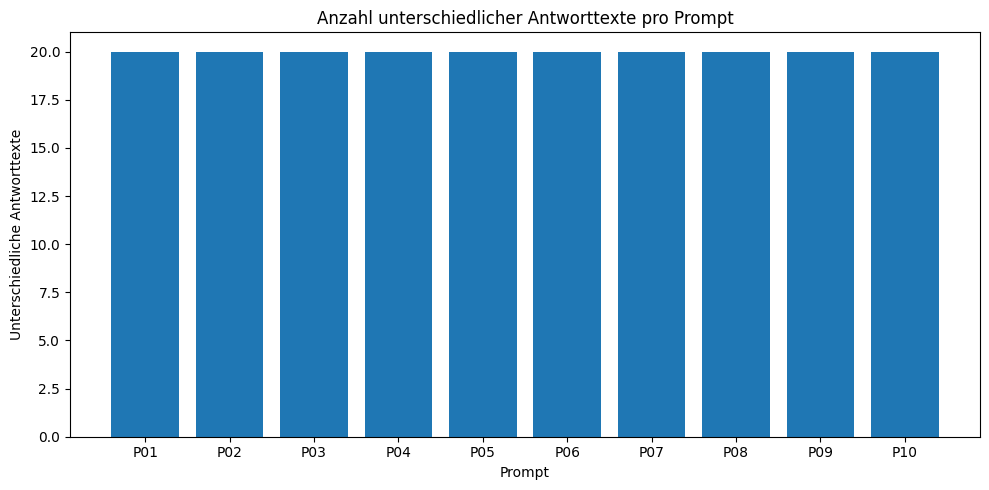

In [16]:
plot_data = text_variants.sort_values('prompt_id')

plt.figure(figsize=(10, 5))
plt.bar(plot_data['prompt_id'], plot_data['different_response_texts'])
plt.title('Anzahl unterschiedlicher Antworttexte pro Prompt')
plt.xlabel('Prompt')
plt.ylabel('Unterschiedliche Antworttexte')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'different_response_texts_by_prompt.png', dpi=200)
plt.show()

## 9. Antwortlänge pro Run

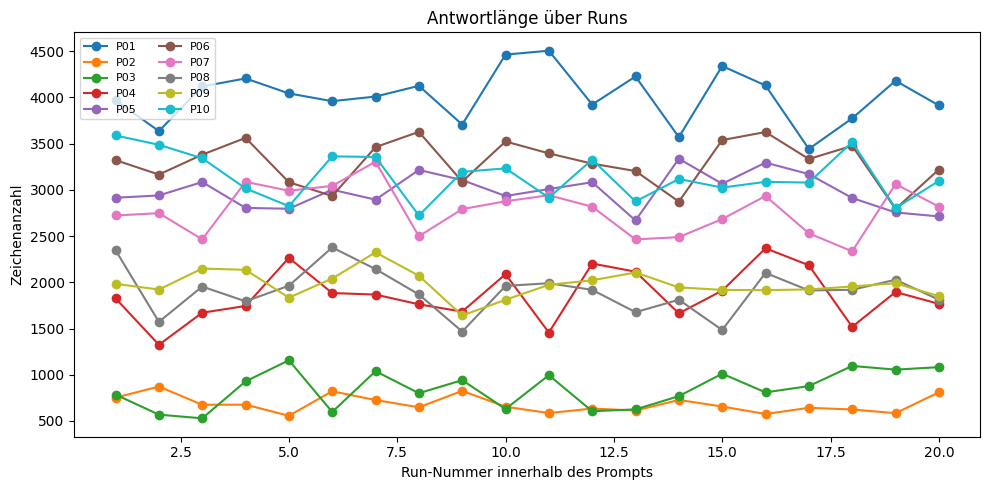

In [17]:
plt.figure(figsize=(10, 5))
for prompt_id, group in raw.sort_values('run_id').groupby('prompt_id'):
    x = list(range(1, len(group) + 1))
    plt.plot(x, group['response_length_chars'], marker='o', label=prompt_id)

plt.title('Antwortlänge über Runs')
plt.xlabel('Run-Nummer innerhalb des Prompts')
plt.ylabel('Zeichenanzahl')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'response_length_over_runs.png', dpi=200)
plt.show()

## 10. Kategorie-Vergleich

In [18]:
category_summary = (
    stability_by_prompt.groupby('category')
    .agg(
        prompts=('prompt_id', 'nunique'),
        mean_url_jaccard=('mean_url_jaccard', 'mean'),
        mean_domain_jaccard=('mean_domain_jaccard', 'mean'),
        min_url_jaccard=('min_url_jaccard', 'min'),
        min_domain_jaccard=('min_domain_jaccard', 'min'),
    )
    .reset_index()
)

category_summary.to_csv(ANALYSIS_DIR / 'category_summary.csv', index=False)
display(category_summary)

,category,prompts,mean_url_jaccard,mean_domain_jaccard,min_url_jaccard,min_domain_jaccard
0,Aktuelles Thema,3,0.155789,0.546424,0.0,0.125
1,Faktische Frage,4,0.148889,0.570828,0.0,0.000
2,Prozedurale Frage,3,0.205219,0.777836,0.0,0.200


## 11. Ergebnisbausteine für das Paper

In [19]:
n_prompts = raw['prompt_id'].nunique()
n_runs = raw['run_id'].nunique()
n_total_answers = len(raw)
n_unique_urls = sources['url'].nunique()
n_unique_domains = sources['domain'].nunique()
all_url_stable = (stability_by_prompt['mean_url_jaccard'] == 1.0).all()
all_domain_stable = (stability_by_prompt['mean_domain_jaccard'] == 1.0).all()

summary_text = f'''
Der Datensatz umfasst {n_prompts} Prompts mit insgesamt {n_total_answers} Antworten. Aus den Antworttexten wurden {len(sources)} URL-Nennungen extrahiert, darunter {n_unique_urls} unterschiedliche URLs und {n_unique_domains} unterschiedliche Domains. Die Quellenextraktion erfolgte per regulärem Ausdruck aus dem generierten Text; es wurden keine Google-Search-Grounding-Metadaten ausgewertet.

Die paarweise Jaccard-Ähnlichkeit der URL-Mengen liegt über alle Prompts hinweg bei {'1.0' if all_url_stable else 'unter 1.0'}. Die Domain-Mengen sind {'ebenfalls vollständig stabil' if all_domain_stable else 'nicht vollständig stabil'}. Dieses Ergebnis spricht für eine hohe Reproduzierbarkeit der textuell genannten Quellen unter den gewählten Bedingungen, insbesondere bei identischen Prompts, identischem Modell und den verwendeten Generierungsparametern.
'''.strip()

print(summary_text)

with (ANALYSIS_DIR / 'paper_result_summary.txt').open('w', encoding='utf-8') as file:
    file.write(summary_text)

Der Datensatz umfasst 10 Prompts mit insgesamt 200 Antworten. Aus den Antworttexten wurden 726 URL-Nennungen extrahiert, darunter 366 unterschiedliche URLs und 85 unterschiedliche Domains. Die Quellenextraktion erfolgte per regulärem Ausdruck aus dem generierten Text; es wurden keine Google-Search-Grounding-Metadaten ausgewertet.

Die paarweise Jaccard-Ähnlichkeit der URL-Mengen liegt über alle Prompts hinweg bei unter 1.0. Die Domain-Mengen sind nicht vollständig stabil. Dieses Ergebnis spricht für eine hohe Reproduzierbarkeit der textuell genannten Quellen unter den gewählten Bedingungen, insbesondere bei identischen Prompts, identischem Modell und den verwendeten Generierungsparametern.
